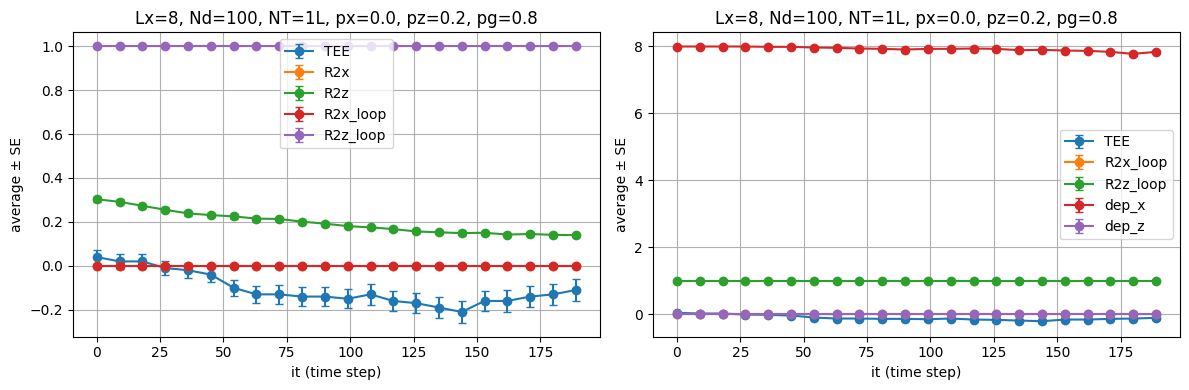

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# 読み込むファイル名
filename = "results_Lx_8_Nd_100_NT_1L_px_0.000_pz_0.200_pg_0.800.npz"
data = np.load(filename)

# ファイル名からパラメータ抽出（Nd, NT, px, pz, pg）
match = re.search(
    r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)L_px_([0-9.]+)_pz_([0-9.]+)_pg_([0-9.]+)(?:\.|$)", filename
)
if match:
    Lx = int(match.group(1))
    Nd = int(match.group(2))
    NT = int(match.group(3))
    px = float(match.group(4))
    pz = float(match.group(5))
    pg = float(match.group(6))
    title_suffix = f"Lx={Lx}, Nd={Nd}, NT={NT}L, px={px}, pz={pz}, pg={pg}"
else:
    title_suffix = os.path.basename(filename)

# 横軸: it (0〜NT-1)
NT = data["TEE"].shape[0]
it_values = np.arange(NT)
stride = max(1, NT // 20)

# 物理量名リスト（プロット順保持のため）
quantities1_names = ["TEE", "R2x", "R2z", "R2x_loop", "R2z_loop"]
quantities2_names = ["TEE", "R2x_loop", "R2z_loop", "dep_x", "dep_z"]

# 平均と標準誤差を計算（axis=1: Nd 平均）
def compute_stats(array):
    mean = np.mean(array, axis=1)
    stderr = np.std(array, axis=1, ddof=1) / np.sqrt(array.shape[1])
    return mean, stderr

# すべての量の統計情報を辞書にまとめる
quantities1 = {name: compute_stats(data[name]) for name in quantities1_names}
quantities2 = {name: compute_stats(data[name]) for name in quantities2_names}

# プロット準備
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# 左プロット
for name in quantities1_names:
    mean, stderr = quantities1[name]
    axs[0].errorbar(it_values[::stride], mean[::stride], yerr=stderr[::stride],
                    marker='o', label=name, capsize=3)
axs[0].set_xlabel("it (time step)")
axs[0].set_ylabel("average ± SE")
axs[0].set_title(f"{title_suffix}")
axs[0].grid(True)
axs[0].legend()

# 右プロット
for name in quantities2_names:
    mean, stderr = quantities2[name]
    axs[1].errorbar(it_values[::stride], mean[::stride], yerr=stderr[::stride],
                    marker='o', label=name, capsize=3)
axs[1].set_xlabel("it (time step)")
axs[1].set_ylabel("average ± SE")
axs[1].set_title(f"{title_suffix}")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()

# PNG保存
output_filename = f"plot_{os.path.splitext(filename)[0]}.png"
plt.savefig(output_filename, dpi=300)
plt.show()


216


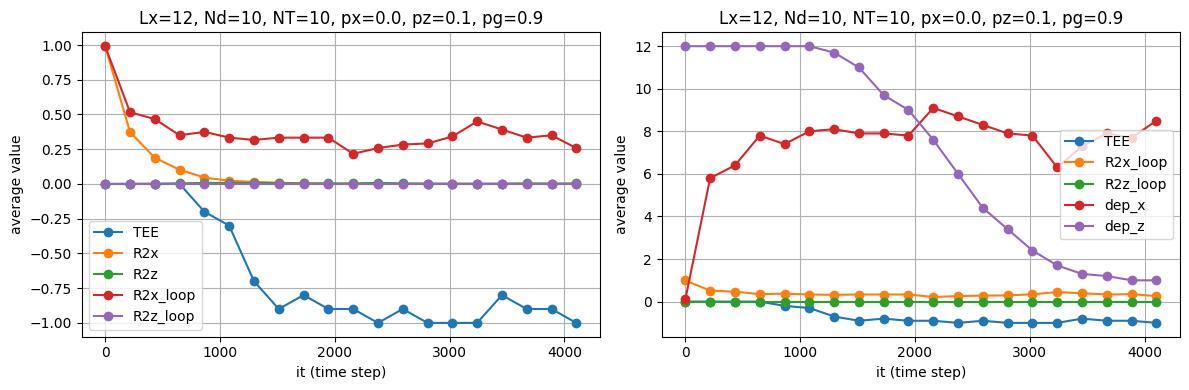

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# 読み込むファイル名
filename = "results_Lx_12_Nd_10_NT_10L_px_0.000_pz_0.100_pg_0.900.npz"
data = np.load(filename)

# ファイル名からパラメータ抽出（Nd, NT, px, pz, pg）
match = re.search(
    r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)L_px_([0-9.]+)_pz_([0-9.]+)_pg_([0-9.]+)(?:\.|$)", filename
)
if match:
    Lx = int(match.group(1))
    Nd = int(match.group(2))
    NT = int(match.group(3))
    px = float(match.group(4))
    pz = float(match.group(5))
    pg = float(match.group(6))
    title_suffix = f"Lx={Lx}, Nd={Nd}, NT={NT}, px={px}, pz={pz}, pg={pg}"
else:
    title_suffix = os.path.basename(filename)

# 横軸: it (0〜NT-1)
NT = data["TEE"].shape[0]
it_values = np.arange(NT)

stride = max(1, NT // 20)  


# 各物理量（Nd 平均）
quantities1 = {
    "TEE": np.mean(data["TEE"], axis=1),
    "R2x": np.mean(data["R2x"], axis=1),
    "R2z": np.mean(data["R2z"], axis=1),
    "R2x_loop": np.mean(data["R2x_loop"], axis=1),
    "R2z_loop": np.mean(data["R2z_loop"], axis=1),
}
quantities2 = {
    "TEE": np.mean(data["TEE"], axis=1),
    "R2x_loop": np.mean(data["R2x_loop"], axis=1),
    "R2z_loop": np.mean(data["R2z_loop"], axis=1),
    "dep_x" : np.mean(data["dep_x"], axis=1),
    "dep_z" : np.mean(data["dep_z"], axis=1),
}


print(stride)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 横に2つのサブプロット

# 左のプロット：TEE, R2x, R2z, R2x_loop, R2z_loop
for name, values in quantities1.items():
    axs[0].plot(it_values[::stride], values[::stride], marker='o', label=name)
axs[0].set_xlabel("it (time step)")
axs[0].set_ylabel("average value")
axs[0].set_title(f"{title_suffix}")
axs[0].grid(True)
axs[0].legend()

# 右のプロット：dep_x と dep_z
for name, values in quantities2.items():
    axs[1].plot(it_values[::stride], values[::stride], marker='o', label=name)
axs[1].set_xlabel("it (time step)")
axs[1].set_ylabel("average value")
axs[1].set_title(f"{title_suffix}")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
output_filename = f"plot_{os.path.splitext(filename)[0]}.png"
plt.savefig(output_filename, dpi=300)  # 高解像度で保存
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import glob

files = glob.glob("results_Nd_*_NT_*_px_*_pz_*_pg_*.npz")
print("見つかったファイル:", files)
data = np.load(files)

for filename in files:
    data = np.load(filename)
# ファイル名からパラメータ抽出（Nd, NT, px, pz, pg）
match = re.search(
    r"Nd_(\d+)_NT_(\d+)_px_([0-9.]+)_pz_([0-9.]+)_pg_([0-9.]+)(?:\.|$)", files
)
if match:
    Nd = int(match.group(1))
    NT = int(match.group(2))
    px = float(match.group(3))
    pz = float(match.group(4))
    pg = float(match.group(5))
    title_suffix = f"Nd={Nd}, NT={NT}, (px, pz, pg)=({px}, {pz}, {pg})"
else:
    title_suffix = os.path.basename(files)

# 横軸: it (0〜NT-1)
NT = data["TEE"].shape[0]
it_values = np.arange(NT)

# 各物理量の平均と標準誤差を計算
quantities_mean = {}
quantities_stderr = {}

for name in ["TEE", "R2x", "R2z", "R2x_loop", "R2z_loop"]:
    vals = data[name]  # shape (NT, Nd) という想定
    mean_vals = np.mean(vals, axis=1)               # it ごとに Nd に沿って平均
    stderr_vals = np.std(vals, axis=1, ddof=1) / np.sqrt(vals.shape[1])  # 標準誤差
    quantities_mean[name] = mean_vals
    quantities_stderr[name] = stderr_vals

# プロット
plt.figure(figsize=(8, 5))
for name in quantities_mean.keys():
    plt.errorbar(it_values, quantities_mean[name], yerr=quantities_stderr[name],
                 marker='o', capsize=3, label=name)

plt.xlabel("it (time step)")
plt.ylabel("average value")
plt.title(f"Nd-averaged quantities vs it\n{title_suffix}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

data.close()


見つかったファイル: ['results_Nd_10_NT_960_px_0.000_pz_0.800_pg_0.200.npz', 'results_Nd_10_NT_960_px_0.000_pz_0.000_pg_1.000.npz', 'results_Nd_10_NT_960_px_0.000_pz_0.400_pg_0.600.npz', 'results_Nd_10_NT_960_px_0.000_pz_0.200_pg_0.800.npz', 'results_Nd_10_NT_960_px_0.000_pz_0.600_pg_0.400.npz', 'results_Nd_10_NT_960_px_0.000_pz_1.000_pg_0.000.npz']


TypeError: expected str, bytes or os.PathLike object, not list

In [37]:
import numpy as np

data = np.load("results_Nd_10_NT_960_px_0.000_pz_0.200_pg_0.800.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE', 'R2x', 'R2z', 'R2x_loop', 'R2z_loop', 'dep_x', 'dep_z']


In [57]:
import numpy as np
np.set_printoptions(threshold=np.inf)
data = np.load("results_Nd_10_NT_960_px_0.000_pz_0.200_pg_0.800.npz")
#print(data['pg'])
#print(data['TEE'])
#print(data['R2x'])
#print(data['R2z'])
#print(data['R2x_loop'])
#print(data['R2z_loop'])
#print(data['dep_x'])
print(data['dep_z'])
data.close()

[[4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
 [4. 4. 4.

In [24]:
import numpy as np

data = np.load("px_0.0_Lx_10_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775
 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975 1.   ]
[ 0.015    0.02125  0.02     0.04625  0.03875  0.03     0.0225   0.0125
 -0.0075  -0.08875 -0.205   -0.37875 -0.495   -0.61375 -0.7025  -0.75125
 -0.84875 -0.88875 -0.93625 -0.96125 -0.99625]
[0.00430022 0.00539995 0.00525924 0.00743019 0.00789071 0.00878045
 0.01013018 0.01075054 0.01323437 0.01681354 0.01796865 0.0194672
 0.01913247 0.01767319 0.01646074 0.01559714 0.01267547 0.01112414
 0.00864296 0.0068278  0.00216235]
[0.014775   0.02329844 0.0221     0.04411094 0.04974844 0.0616
 0.08199375 0.09234375 0.13994375 0.22587344 0.257975   0.30279844
 0.292475   0.24956094 0.21649375 0.19437344 0.12837344 0.09887344
 0.05968594 0.03724844 0.00373594]


見つかったファイル: ['pz_0.0_Lx_10_MPI_results.npz']
pz_0.0_Lx_10_MPI_results.npz: pg = [0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775
 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975 1.   ]


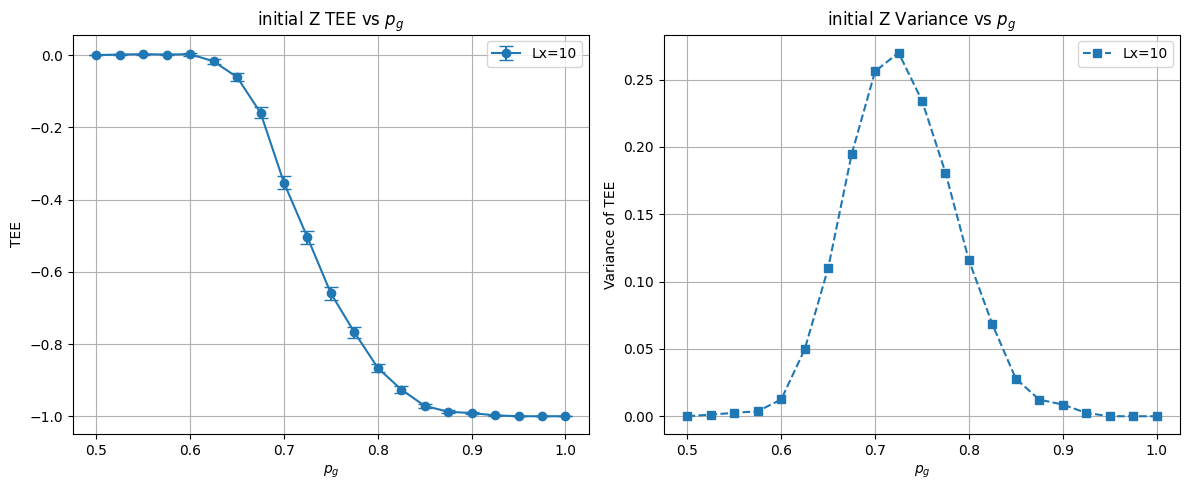

In [19]:
#### initial Z
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

cmap = plt.colormaps['gnuplot']

# ファイル読み込み（Lxの数字を含むもの）
files = glob.glob("pz_0.0_Lx_*_MPI_results.npz")
print("見つかったファイル:", files)

# --- Lxの数値でソート ---
lx_file_pairs = []
for file in files:
    match = re.search(r'Lx_(\d+)', file)
    if match:
        Lx = int(match.group(1))
        lx_file_pairs.append((Lx, file))
    else:
        print(f"Lxの抽出失敗: {file}")

# 数値順に並べ替え（10, 12, 14, 16...）
lx_file_pairs.sort(key=lambda x: x[0])

# プロット用
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for Lx, file in lx_file_pairs:
    with np.load(file) as data:
        pg = data['pg']
        TEE_ave = data['TEE_ave']
        TEE_err = data['TEE_err']
        TEE_var = data['TEE_var']

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)
    print(f"{file}: pg = {pg}")

# 描画設定
ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('TEE')
ax[0].set_title('initial Z TEE vs $p_g$')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('$p_g$')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('initial Z Variance vs $p_g$')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig("pz_0.0"+"_Lx_"+"{:}".format(Lx)+"_MPI_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
import numpy as np

data = np.load("pz_0.0_Lx_10_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775
 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975 1.   ]
[ 0.    0.    0.    0.    0.    0.   -0.02 -0.2  -0.22 -0.58 -0.52 -0.76
 -0.78 -0.92 -0.96 -1.   -0.98 -1.   -1.   -1.   -1.  ]
[0.         0.         0.         0.         0.         0.02857143
 0.02       0.06388766 0.06571429 0.07050836 0.07137141 0.06101188
 0.05917804 0.03875617 0.02799417 0.         0.02       0.
 0.         0.         0.        ]
[0.     0.     0.     0.     0.     0.04   0.0196 0.2    0.2116 0.2436
 0.2496 0.1824 0.1716 0.0736 0.0384 0.     0.0196 0.     0.     0.
 0.    ]


In [36]:
import numpy as np

data = np.load("pz_0.0_Lx_10_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775
 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975 1.   ]
[ 0.    0.    0.    0.    0.    0.   -0.02 -0.2  -0.22 -0.58 -0.52 -0.76
 -0.78 -0.92 -0.96 -1.   -0.98 -1.   -1.   -1.   -1.  ]
[0.         0.         0.         0.         0.         0.02857143
 0.02       0.06388766 0.06571429 0.07050836 0.07137141 0.06101188
 0.05917804 0.03875617 0.02799417 0.         0.02       0.
 0.         0.         0.        ]
[0.     0.     0.     0.     0.     0.04   0.0196 0.2    0.2116 0.2436
 0.2496 0.1824 0.1716 0.0736 0.0384 0.     0.0196 0.     0.     0.
 0.    ]
